# EDA - 11term_ai Car Pricing

Narrative EDA document. All tables and figures are loaded from already-generated
files in `outputs/reports/` and `outputs/figures/` — no raw data transforms or
new computations happen in this notebook.

## S1 - Dataset Profile

In [7]:
import pandas as pd

dataset_summary = pd.read_csv('../outputs/reports/dataset_summary.csv')
dataset_summary

,Rows,Columns,Missing values,Duplicates
0,53544,13,6823,0


In [8]:
missing_values = pd.read_csv('../outputs/reports/missing_values.csv')
missing_values

,column,missing_count
0,make,0
1,model,0
2,priceUSD,0
3,year,0
4,condition,0
5,mileage(kilometers),0
6,fuel_type,0
7,volume(cm3),47
8,color,0
9,transmission,0


#### **Summary:** Missing values are concentrated in three columns  
- `volume(cm3)` (47 nulls, negligible),  
- `drive_unit` (1,765 nulls, a moderate gap likely tied to listings where the seller omitted drivetrain info), and  
- `segment` (5,011 nulls, the largest gap by far). 
    - `segment` is a manually collected field (per original scope), so its unlikely random, m
    - more likely it reflects data collection effort rather than a property of the car itself.  
- All three gaps are candidates for imputation rather than row-drop given their scale
relative to the 56,244-row dataset.  

In [9]:
# Spot check: fuel_type for rows where volume(cm3) is null
# expecting large number are electric
df_raw = pd.read_csv('../data/cars.csv')

missing_vol = df_raw[df_raw['volume(cm3)'].isna()]
print(f"Total missing volume(cm3): {len(missing_vol)}")
print()
print("fuel_type breakdown:")
print(missing_vol['fuel_type'].value_counts(dropna=False))

Total missing volume(cm3): 47

fuel_type breakdown:
fuel_type
electrocar    47
Name: count, dtype: int64


#### **Decision:** confirmed NaN for `volume` directly relates to electric motors  
- simple imputation to fill

## S2 - Price Distribution

![Price histogram](../outputs/figures/histogram_priceUSD.png)

![Price boxplot](../outputs/figures/boxplot_priceUSD.png)
  
**Summary:** `priceUSD` is strongly right-skewed  
- the bulk of listings sit in a low-to-mid price band with a long tail stretching toward the high end.  
- The boxplot shows a dense cluster of outliers above the upper whisker, consistent with a small number of premium/luxury listings pulling the mean well above the median. 
- This skew is a strong candidate for a log transform at modeling time.

## S3 - Mileage Distribution

![Mileage histogram](../outputs/figures/histogram_mileage(kilometers).png)

![Mileage boxplot](../outputs/figures/boxplot_mileage(kilometers).png)

**Summary:** `mileage(kilometers)` is also right-skewed, with most cars
clustered at moderate mileage and a thinning tail of high-mileage outliers.  

The spread is wide relative to the median, reflecting the mixed age range
of the fleet (`year` spans 1990–2019).  

## S4 - Engine Volume Distribution

![Engine volume histogram](../outputs/figures/histogram_volume(cm3).png)
  
**Summary:** `volume(cm3)` shows a roughly multimodal shape, with peaks
around common engine displacement classes.  
- The 47 null values noted in S1 are negligible in count and are planned for EV-imputation (PP-08) rather than row removal.

In [12]:
# Find price ranges for standard engine size groups
import numpy as np

df_vol = df_raw.copy()
df_vol['volume(cm3)'] = df_vol['volume(cm3)'].fillna(0)

bands = [0, 1, 1400, 1800, 2200, 2800, 3500, 20001]
labels = ['ev', 'micro(<1400)', 'small(1400-1800)', 'medium(1800-2200)', 
          'large(2200-2800)', 'xl(2800-3500)', 'truck(3500+)']

df_vol['engine_band'] = pd.cut(df_vol['volume(cm3)'], bins=bands, 
                                labels=labels, include_lowest=True)

summary = df_vol.groupby('engine_band', observed=True)['priceUSD'].describe().round(0)
summary.insert(0, 'count', summary.pop('count'))

pd.set_option('display.max_columns', None)
summary

,count,mean,std,min,25%,50%,75%,max
engine_band,,,,,,,,
ev,47.0,36848.0,35679.0,2700.0,12925.0,15649.0,52000.0,161563.0
micro(<1400),6079.0,4800.0,4024.0,48.0,1500.0,4000.0,7000.0,37500.0
small(1400-1800),18135.0,5593.0,4848.0,95.0,1599.0,4000.0,8700.0,90000.0
medium(1800-2200),17338.0,6918.0,7182.0,100.0,2450.0,4541.0,8700.0,118000.0
large(2200-2800),7447.0,7305.0,5912.0,210.0,3327.0,5850.0,9500.0,82326.0
xl(2800-3500),4826.0,14695.0,12681.0,300.0,7337.0,11400.0,17899.0,148000.0
truck(3500+),2372.0,16642.0,18047.0,150.0,7300.0,11900.0,18592.0,235235.0


**Decision:**  
- `micro` and `small` share identical medians ($4,000);  
- `xl` and `truck` are within $500 of each other ($11,400 vs $11,900).   
- Merged into 5 bins: `ev`, `small`(≤1600), `medium`, `large`, `xl_plus`(>3000).  

## S5 - Mileage vs Price

![Mileage vs price scatter](../outputs/figures/scatter_mileage(kilometers)_vs_priceUSD.png)

**Summary:** There is a visible negative trend  
- price declines as mileage increases  
- but the relationship is noisy rather than a clean line,  
    - with a dense low-mileage/low-to-mid-price cluster and a long thinning tail at high mileage.  
- The steepest drop-off appears at the low end of the mileage range, flattening out afterward, which could inform where to place mileage bin boundaries.

### Mileage investigation

In [11]:
# Overall mileage distribution and rough bands:

import pandas as pd
from config import TRAIN_FILE
from pathlib import Path
from data_loader import load_data

df_raw = load_data(Path(TRAIN_FILE))

print('=== mileage(kilometers) distribution ===')
print(df_raw['mileage(kilometers)'].describe().round(0))
print()
print('Percentiles:')
for p in [5, 10, 25, 50, 75, 90, 95, 99]:
    print(f'  p{p}: {df_raw["mileage(kilometers)"].quantile(p/100):.0f}')
print()

print('Median priceUSD by rough mileage band:')
bands = [0, 50000, 100000, 150000, 200000, 250000, 999999]
labels = ['0-50k', '50-100k', '100-150k', '150-200k', '200-250k', '250k+']
df_raw['mil_band'] = pd.cut(df_raw['mileage(kilometers)'], bins=bands, labels=labels, include_lowest=True)
summary = df_raw.groupby('mil_band', observed=True)['priceUSD'].describe().round(0)
print(summary)


=== mileage(kilometers) distribution ===
count      56244.0
mean      244396.0
std       321031.0
min            0.0
25%       137000.0
50%       228500.0
75%       310000.0
max      9999999.0
Name: mileage(kilometers), dtype: float64

Percentiles:
  p5: 2731
  p10: 54000
  p25: 137000
  p50: 228500
  p75: 310000
  p90: 385000
  p95: 431000
  p99: 630000

Median priceUSD by rough mileage band:
            count     mean      std    min     25%      50%      75%       max
mil_band                                                                      
0-50k      5419.0  10106.0  15717.0   48.0  1650.0   4980.0  12000.0  235235.0
50-100k    4239.0  13392.0  12337.0  143.0  6750.0  10850.0  16300.0  195000.0
100-150k   6509.0  11286.0   8263.0  150.0  6100.0   9750.0  14300.0   90000.0
150-200k   8165.0   9382.0   6902.0  100.0  4900.0   8000.0  12500.0  150000.0
200-250k   8084.0   6709.0   5147.0  133.0  2890.0   5750.0   9100.0   49000.0
250k+     23441.0   4284.0   3536.0  100.0  1700.0

In [16]:
# Deep dive: 0-100k car age analysis:

print('=== CAR AGE in 0-10k mileage band ===')
df_raw['car_age'] = 2019 - df_raw['year']  

low = df_raw[df_raw['mileage(kilometers)'] <= 10000]
print(low['car_age'].describe().round(1))
print()

print('=== PRICE by mileage sub-bands (0-100k) ===')
band_df = df_raw[df_raw['mileage(kilometers)'] <= 100000].copy()
bins_detail = [0, 10000, 25000, 50000, 75000, 100000]
labels_detail = ['0-10k', '10-25k', '25-50k', '50-75k', '75-100k']
band_df['mil_detail'] = pd.cut(band_df['mileage(kilometers)'], bins=bins_detail, labels=labels_detail, include_lowest=True)
print(band_df.groupby('mil_detail', observed=True)['priceUSD'].describe().round(0))
print()

print('=== TOP 3 MAKES: median price across 50-120k bands ===')
top3 = df_raw['make'].value_counts().head(3).index.tolist()
band_50_120 = df_raw[(df_raw['mileage(kilometers)'] >= 50000) & (df_raw['mileage(kilometers)'] <= 120000)].copy()
band_50_120 = band_50_120[band_50_120['make'].isin(top3)]
bins_50_120 = [50000, 60000, 75000, 90000, 100000, 120000]
labels_50_120 = ['50-60k', '60-75k', '75-90k', '90-100k', '100-120k']
band_50_120['mil_band'] = pd.cut(band_50_120['mileage(kilometers)'], bins=bins_50_120, labels=labels_50_120, include_lowest=True)
print(band_50_120.groupby(['make', 'mil_band'], observed=True)['priceUSD'].median().unstack().round(0))



=== CAR AGE in 0-10k mileage band ===
count    3209.0
mean       18.5
std        10.2
min         0.0
25%        12.0
50%        19.0
75%        24.0
max        86.0
Name: car_age, dtype: float64

=== PRICE by mileage sub-bands (0-100k) ===
             count     mean      std    min     25%      50%      75%  \
mil_detail                                                              
0-10k       3209.0   7220.0  13670.0   95.0  1400.0   3400.0   7200.0   
10-25k       679.0  14679.0  18013.0   48.0  2560.0  10800.0  18125.0   
25-50k      1531.0  14128.0  17211.0  150.0  2700.0  10500.0  17106.0   
50-75k      1736.0  15269.0  14475.0  150.0  7774.0  11900.0  18900.0   
75-100k     2503.0  12090.0  10410.0  143.0  6000.0  10000.0  15000.0   

                 max  
mil_detail            
0-10k       170000.0  
10-25k      183848.0  
25-50k      235235.0  
50-75k      195000.0  
75-100k      97000.0  

=== TOP 3 MAKES: median price across 50-120k bands ===
mil_band     50-60k   60-75k  

In [23]:
# Deep dive: >100k car age analysis:

print('=== CAR AGE in >100k mileage band ===')
df_raw['car_age'] = 2019 - df_raw['year']  

high = df_raw[df_raw['mileage(kilometers)'] > 100000]
print(high['car_age'].describe().round(1))
print()

print('=== PRICE by mileage sub-bands (>100k) ===')
band_df = df_raw[df_raw['mileage(kilometers)'] > 100000].copy()
bins_detail = [100000, 200000, 250000, 350000, 450000, 600000, 999999]
labels_detail = ['100k-200k', '200k-250k', '250k-350k', '350-450k', '450-600k', '>600k']
band_df['mil_detail'] = pd.cut(band_df['mileage(kilometers)'], bins=bins_detail, labels=labels_detail, include_lowest=True)
print(band_df.groupby('mil_detail', observed=True)['priceUSD'].describe().round(0))
print()

print('=== TOP 3 MAKES: median price across >100k bands ===')
top3 = df_raw['make'].value_counts().head(3).index.tolist()
band_100_600 = df_raw[(df_raw['mileage(kilometers)'] >= 100000) & (df_raw['mileage(kilometers)'] <= 600000)].copy()
band_100_600 = band_100_600[band_100_600['make'].isin(top3)]
bins_100_600 = [100000, 200000, 250000, 350000, 450000, 600000, 999999]
labels_100_600 = ['100k-200k', '200k-250k', '250k-350k', '350-450k', '450-600k', '>600k']
band_100_600['mil_band'] = pd.cut(band_100_600['mileage(kilometers)'], bins=bins_100_600, labels=labels_100_600, include_lowest=True)
print(band_100_600.groupby(['make', 'mil_band'], observed=True)['priceUSD'].median().unstack().round(0))



=== CAR AGE in >100k mileage band ===
count    46586.0
mean        16.2
std          7.2
min          0.0
25%         11.0
50%         16.0
75%         21.0
max         83.0
Name: car_age, dtype: float64

=== PRICE by mileage sub-bands (>100k) ===
              count     mean     std    min     25%     50%      75%       max
mil_detail                                                                    
100k-200k   14674.0  10226.0  7595.0  100.0  5437.0  8860.0  13448.0  150000.0
200k-250k    8084.0   6709.0  5147.0  133.0  2890.0  5750.0   9100.0   49000.0
250k-350k   15517.0   4568.0  3793.0  100.0  1800.0  3565.0   6200.0   36000.0
350-450k     6183.0   3856.0  2939.0  100.0  1700.0  3200.0   5229.0   26000.0
450-600k     1526.0   3350.0  2649.0  150.0  1400.0  2750.0   4500.0   21900.0
>600k         215.0   2725.0  2562.0  143.0   800.0  1700.0   3850.0   12900.0

=== TOP 3 MAKES: median price across >100k bands ===
mil_band    100k-200k  200k-250k  250k-350k  350-450k  450-600k
ma

In [24]:
# 6-bin summary check

print('=== FINAL MILEAGE BINS: 6-category breakdown ===')
df_final = df_raw.copy()
df_final['mileage(kilometers)'] = df_final['mileage(kilometers)'].clip(upper=600000)

final_bins = [0, 10000, 50000, 100000, 200000, 250000, 350000, 600001]
final_labels = ['very_low', 'low', 'average', 'moderate', 'high','very_high', 'end_of_life']
df_final['mileage_band'] = pd.cut(df_final['mileage(kilometers)'], 
                                    bins=final_bins, labels=final_labels, include_lowest=True)

final_summary = df_final.groupby('mileage_band', observed=True)['priceUSD'].describe().round(0)
final_summary.insert(0, 'count', final_summary.pop('count'))
print(final_summary)


=== FINAL MILEAGE BINS: 6-category breakdown ===
                count     mean      std    min     25%      50%      75%  \
mileage_band                                                               
very_low       3209.0   7220.0  13670.0   95.0  1400.0   3400.0   7200.0   
low            2210.0  14297.0  17459.0   48.0  2700.0  10525.0  17500.0   
average        4239.0  13392.0  12337.0  143.0  6750.0  10850.0  16300.0   
moderate      14674.0  10226.0   7595.0  100.0  5437.0   8860.0  13448.0   
high           8084.0   6709.0   5147.0  133.0  2890.0   5750.0   9100.0   
very_high     15517.0   4568.0   3793.0  100.0  1800.0   3565.0   6200.0   
end_of_life    8311.0   3654.0   2888.0  100.0  1500.0   3000.0   5000.0   

                   max  
mileage_band            
very_low      170000.0  
low           235235.0  
average       195000.0  
moderate      150000.0  
high           49000.0  
very_high      36000.0  
end_of_life    26000.0  


**Summary:** 100k km marks a clear psychological/mechanical threshold.  
Price drops sharply from 50-100k ($10.8k median) to 100-200k ($8.0k median).  
The 0-10k band separates distinctly (median $4.9k, mean car age 18.5 yrs) suggesting stored/low-use vehicles rather than genuinely new cars.  

## S6 - Brand Influence

![Price by make grouped boxplot](../outputs/figures/grouped_boxplot_make.png)

![Make counts](../outputs/figures/categorical_make.png)

In [5]:
median_price_by_make = pd.read_csv('../outputs/reports/median_priceUSD_by_make.csv')
median_price_by_make

,make,median_priceUSD
0,bentley,145238.5
1,mclaren,121500.0
2,aston-martin,95000.0
3,tesla,63200.0
4,maserati,39900.0
...,...,...
90,fso,892.5
91,zaz,750.0
92,proton,675.0
93,izh,500.0


**Summary** Median price by make spans a wide range,  
- a clear split between premium brands multiples of the median price (budget
brands)  
- grouped boxplot shows not just a shift in median but a difference in spread  
- premium makes tend to have wider price ranges,  
    - consistent with a broader range of trims/conditions being sold under those
brands.

In [ ]:
# `Make` tier analysis - by median price with count and percentiles
make_profile = df_raw.groupby('make')['priceUSD'].agg(
    count='count',
    median='median',
    p25=lambda x: x.quantile(0.25),
    p75=lambda x: x.quantile(0.75),
    max='max'
).sort_values('median', ascending=False).round(0)
pd.set_option('display.max_rows', None)

make_profile

,count,median,p25,p75,max
make,,,,,
bentley,9,170477.0,73000.0,190141.0,235235
mclaren,1,121500.0,121500.0,121500.0,121500
aston-martin,1,95000.0,95000.0,95000.0,95000
tesla,16,63200.0,44750.0,94250.0,161563
maserati,5,39900.0,11000.0,54500.0,88900
porsche,175,19800.0,10150.0,31000.0,170000
jaguar,78,19500.0,10900.0,28875.0,78900
haval,5,17350.0,17350.0,19100.0,29000
dong-feng,1,15000.0,15000.0,15000.0,15000


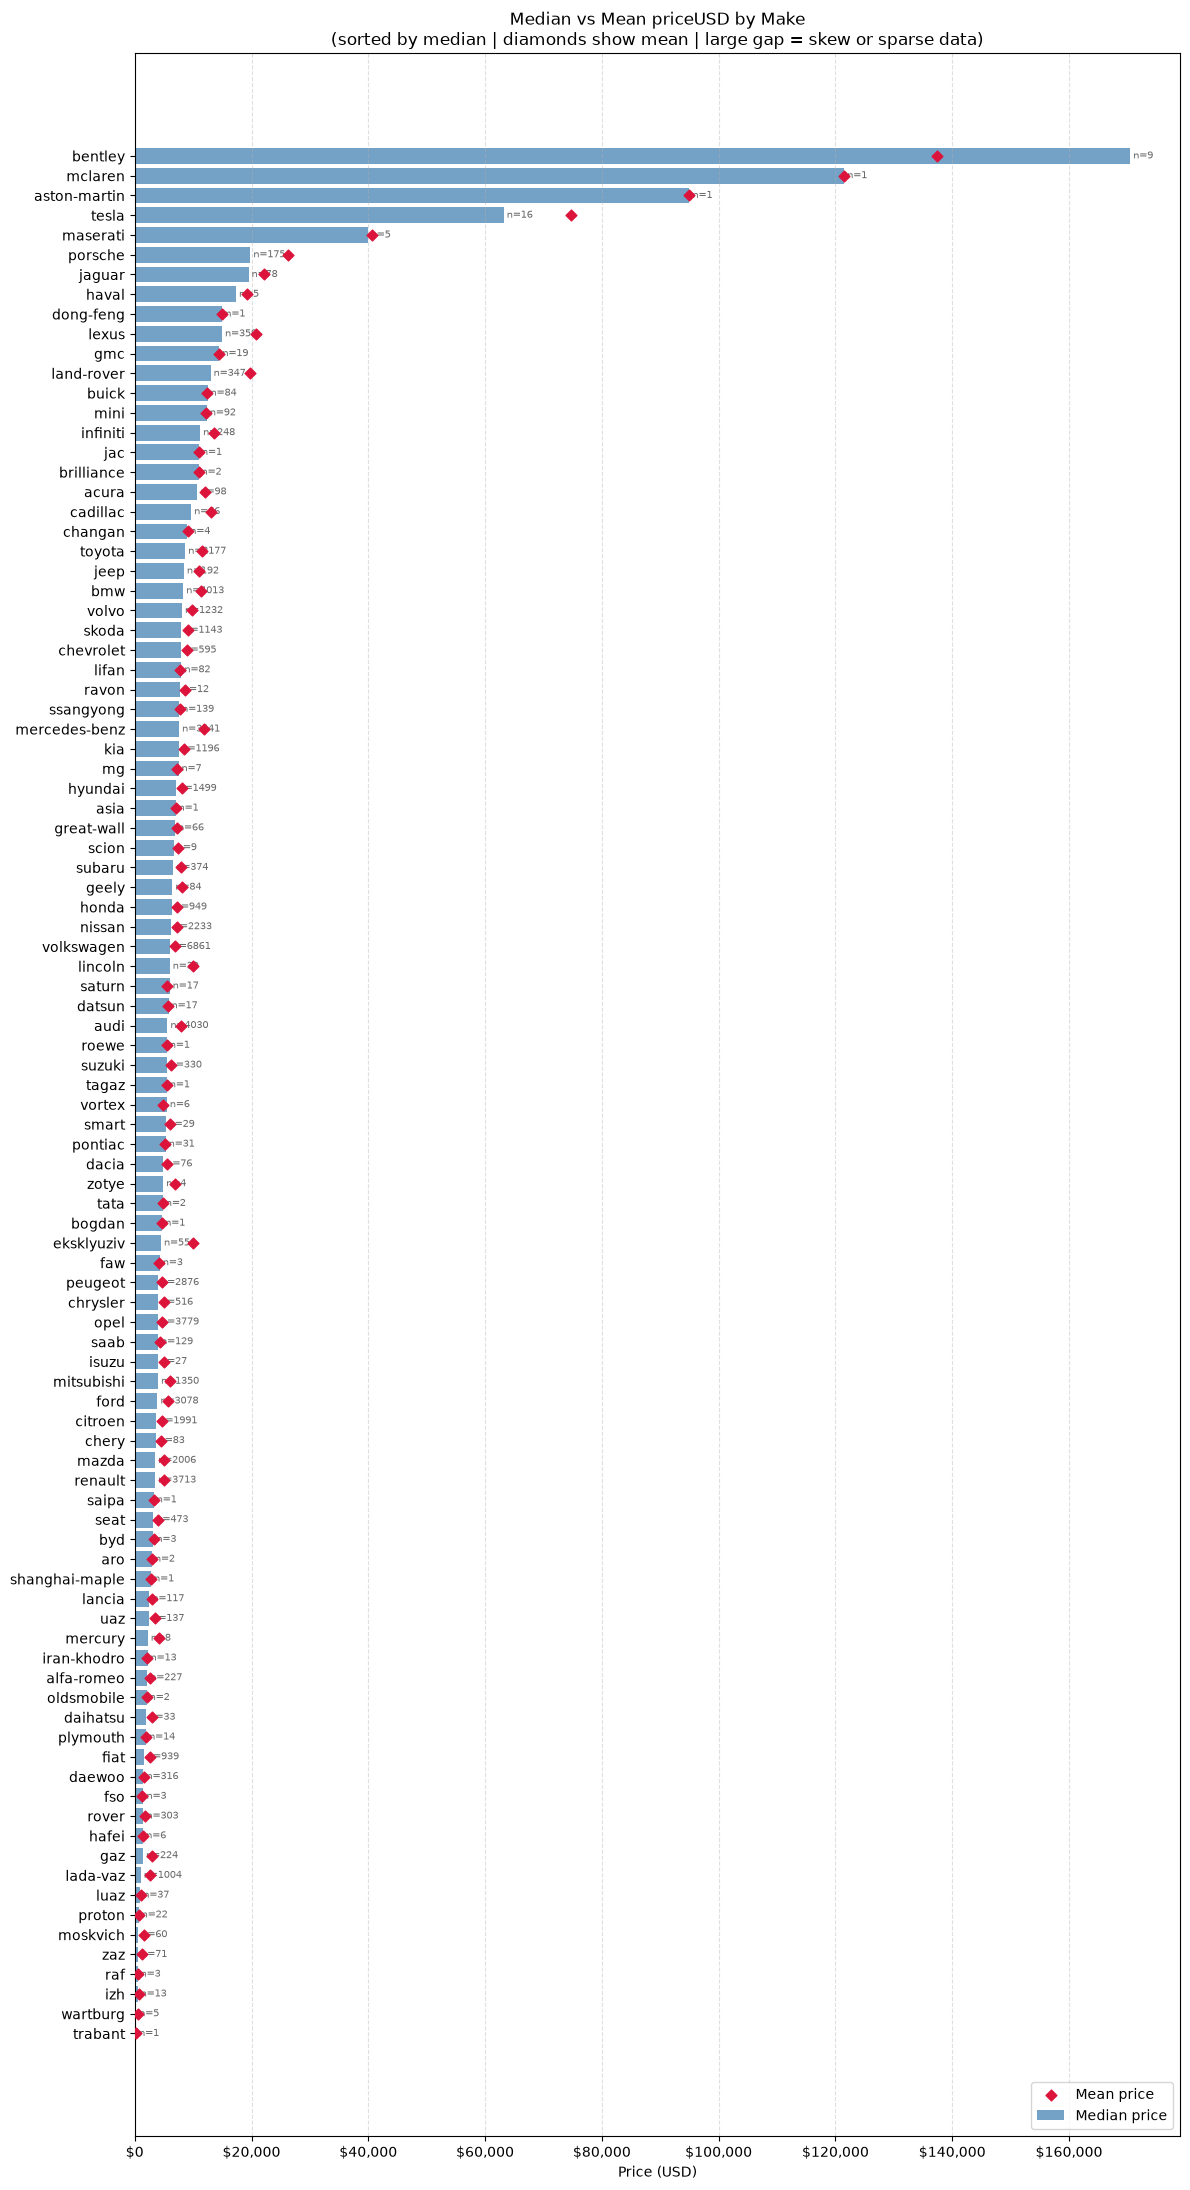

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df_raw = pd.read_csv('../data/cars.csv')

make_stats = df_raw.groupby('make')['priceUSD'].agg(
    median='median',
    mean='mean',
    count='count'
).sort_values('median', ascending=True)  # ascending for horizontal bar readability

fig, ax = plt.subplots(figsize=(12, 22))

# Bars — median price
bars = ax.barh(make_stats.index, make_stats['median'], color='steelblue', alpha=0.75, label='Median price')

# Overlay — mean price as diamond marker
ax.scatter(make_stats['mean'], make_stats.index, color='crimson', marker='D',
           s=30, zorder=5, label='Mean price')

# Count annotation on each bar
for i, (make, row) in enumerate(make_stats.iterrows()):
    ax.text(row['median'] + 500, i, f"n={int(row['count'])}", va='center', fontsize=7, color='dimgray')

ax.set_xlabel('Price (USD)')
ax.set_title('Median vs Mean priceUSD by Make\n(sorted by median | diamonds show mean | large gap = skew or sparse data)', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(loc='lower right')
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/figures/make_price_tier_analysis.png', dpi=150)
plt.show()

In [16]:
make_stats = df_raw.groupby('make')['priceUSD'].agg(
    count='count',
    median='median',
    mean='mean',
    p75=lambda x: x.quantile(0.75),
    std='std',
).round(0)

make_stats['mean_median_ratio'] = (make_stats['mean'] / make_stats['median']).round(2)
make_stats = make_stats.sort_values("mean_median_ratio", ascending=False)

pd.set_option('display.max_rows', None)
make_stats


,count,median,mean,p75,std,mean_median_ratio
make,,,,,,
moskvich,60,620.0,1607.0,1409.0,2567.0,2.59
lada-vaz,1004,1043.0,2700.0,3200.0,3441.0,2.59
eksklyuziv,55,4500.0,10051.0,14995.0,13128.0,2.23
wartburg,5,252.0,552.0,1000.0,506.0,2.19
gaz,224,1426.0,3043.0,3000.0,4853.0,2.13
zaz,71,600.0,1186.0,1875.0,1182.0,1.98
mercury,8,2250.0,4075.0,6175.0,3859.0,1.81
lincoln,39,6000.0,9963.0,10450.0,12072.0,1.66
fiat,939,1600.0,2628.0,3225.0,2928.0,1.64


#### **Decision:** Make Tier Classification:  

Brand (`make`) has 96 unique values — too many for direct one-hot encoding.
Instead, makes are grouped into 5 pricing tiers using a rule-based classifier
anchored to market data and domain knowledge.

**Tier Assignment Rules**
Applied in priority order:

| Rule | Tier |
|---|---|
| p75 > $35,000 | luxury |
| p75 > $20,000 | premium |
| p75 > $5,500 AND count ≥ 7 AND ratio ≤ 1.75 | standard |
| p75 ≤ $5,500 AND count ≥ 7 AND ratio ≤ 1.75 | budget |
| all others | regional |

`ratio` = mean/median; values > 1.75 indicate high internal price variance
or sparse/unreliable data, and are routed to regional regardless of count.

**Tier Summary**

| Tier | Makes (n) | Examples |
|---|---|---|
| luxury | 5 | bentley, tesla, maserati, mclaren, aston-martin |
| premium | 4 | porsche, jaguar, lexus, land-rover |
| standard | 45 | volkswagen, bmw, toyota, honda, ford, audi, mercedes-benz |
| budget | 13 | fiat, daewoo, rover, alfa-romeo, lancia, daihatsu |
| regional | 29 | lada-vaz, gaz, eksklyuziv, zaz, moskvich + sparse/discontinued |

**Notes**
- `eksklyuziv` routed to regional: ratio 2.23 indicates an inconsistent
  listing source, not a true manufacturer tier
- `mercury`, `zaz`, `lada-vaz`, `gaz`, `moskvich` routed to regional
  via ratio filter despite meaningful row counts
- `land-rover` placed in premium via domain override; mean/p75 support it
  despite median sitting near the standard boundary
- Chinese and discontinued American brands fall by data rules, no manual override

## S7 - Categorical Feature Distributions

![Fuel type counts](../outputs/figures/categorical_fuel_type.png)

**Summary:** Two fuel types dominate the listings,
- with 'electric' making up a small share 
- watch for imbalance if `fuel_type` is used as a categorical predictor.
  

![Transmission counts](../outputs/figures/categorical_transmission.png)

**Summary:** Transmission type shows a skew toward one dominant category,  
- similar to fuel type  
- the minority class(es) have less data for learning transmission price effect


![Drive unit counts](../outputs/figures/categorical_drive_unit.png)

**Summary:** `drive_unit` has a dominant category  
- plus a visible "missing" concern (1,765 nulls per S1).  
- Distribution across the remaining categories is uneven, 
    - which should be considered when choosing an imputation strategy.
- worth consideration evaluation if significant price difference correlates between 'front' vs all others.

In [6]:
# Profile rows where drive_unit is missing
missing_du = df_raw[df_raw['drive_unit'].isna()]

print(f"Total missing drive_unit: {len(missing_du)}")
print(f"% of total dataset: {round(len(missing_du)/len(df_raw)*100, 2)}%")
print()
print("Median price USD by drive_unit (including NaN):")
print(df_raw.groupby('drive_unit', dropna=False)['priceUSD'].median().sort_values(ascending=False))
print()
print("Missing drive_unit — count by make (top 15):")
print(missing_du['make'].value_counts().head(15))
print()
print("Describe of missing drive_unit rows:")
print(missing_du[['priceUSD', 'year', 'mileage(kilometers)', 'volume(cm3)']].describe().round(1))

Total missing drive_unit: 1905
% of total dataset: 3.39%

Median price USD by drive_unit (including NaN):
drive_unit
all-wheel drive               12740.0
part-time four-wheel drive    10000.0
rear drive                     4500.0
front-wheel drive              4400.0
NaN                            3950.0
Name: priceUSD, dtype: float64

Missing drive_unit — count by make (top 15):
make
volkswagen       236
renault          162
opel             140
audi             114
peugeot          111
ford             109
bmw              105
mercedes-benz     95
citroen           86
toyota            81
nissan            72
mazda             58
hyundai           51
lada-vaz          50
fiat              46
Name: count, dtype: int64

Describe of missing drive_unit rows:
       priceUSD    year  mileage(kilometers)  volume(cm3)
count    1905.0  1905.0               1905.0       1903.0
mean     6078.6  2001.6             236788.7       2041.0
std      7253.0     9.1             280363.9       1209.8


**Decision:** based on average price and primary 'make' values,  
- use majority-vote imputation based on make, rather than dropping or 'unknown'  
- then one-hot encoding to preserve purchase decision factors (and correlated price)   

![Condition counts](../outputs/figures/categorical_condition.png)

**Summary:** `condition` is concentrated one category,  
- candidate for imbalance-aware handling  
- or  distinct bin division between 'mileage' and 'damaged or parts'

## S8 - Segment Patterns

`Segment` is likely from the standard labeling system  
"European Commission vehicle segment classification".  
Code and common names listed below.  

| Code | Segment Name |
| --- | --- |
| A |	City / Mini|
| B	| Subcompact / Small |
| C	| Compact / Lower-medium |
| D	| Mid-size / Upper-medium |
| E	| Executive / Large |
| F	| Luxury / Full-size |
| J	| SUV / Off-road |
| M	| MPV / Minivan |
| S	| Sports coupe |

![Segment counts](../outputs/figures/categorical_segment.png)

![Price by segment grouped boxplot](../outputs/figures/grouped_boxplot_segment.png)

**Note: `segment` is a manually collected field and may be noisy.**  
- Values assigned to this column depend on input 
    - rather than a derived or validated property of the car, 
- patterns here should be treated as suggestive rather than authoritative.

**Summary:** Price varies noticeably across segments,   
- with some segments showing materially higher medians 
- logical given segment represents vehicle class. 
- `segment` also has the largest missing values of any column (5,011 nulls); 
    - a majority-vote imputation strategy is planned fill these gaps.
- the encoded symbols likely correlate to a standard indicator by EU or US standards

#### **Decision:** Since segment is potentially unreliable and has meaningful price impact value, we are creating 3 bins:  
- `standard`: A-F + M - for similar customer and use purpose  
- `SUV/Off-road`: J - for more specialized use purpose and larger price spread  
- `Sport`: S - for specialized category of customer and price  

## S9 - Correlation Structure

![Correlation heatmap](../outputs/figures/heatmap.png)

**Summary:** numeric features  
- `car_age` shows the strongest (negative) correlation with `priceUSD`  
    - older cars are worth less, as expected.  
- `mileage(kilometers)` also negatively correlated with price,  
    - consistent with Mileage vs Price scatter plot 
- `volume(cm3)` shows a weaker, positive relationship with price.  
- `year` and `car_age` have strongly opposed correlations with each other  
    - as expected they are extremely similar representations  
    - only one should be used as a model feature.

## S10 Model(Make/Model) inspection

In [9]:
# Model deep dive
import pandas as pd
from config import TRAIN_FILE
from pathlib import Path
from data_loader import load_data
df_raw = load_data(Path(TRAIN_FILE))

top_makes = df_raw.groupby('make').size().nlargest(10).index
top_colors = df_raw.groupby('color').size().nlargest(100).index
model_check = df_raw[df_raw['make'].isin(top_makes)].groupby(['make', 'model']).size().reset_index(name='count')
colors_check = df_raw[df_raw['color'].isin(top_colors)].groupby(['make', 'model']).size().reset_index(name='count')
pd.set_option('display.max_rows', None)
print(model_check)
print(colors)

              make                   model  count
0             audi                     100    582
1             audi                     200      9
2             audi                      80    459
3             audi                      90     16
4             audi                      a1     12
5             audi                      a2      5
6             audi                      a3    120
7             audi                      a4    704
8             audi              a4-allroad      7
9             audi                      a5     73
10            audi                      a6   1276
11            audi              a6-allroad     71
12            audi                      a7     31
13            audi                      a8    277
14            audi                   coupe      6
15            audi                      q3     34
16            audi                      q5    118
17            audi                      q7    163
18            audi                      q8      1


In [20]:
# Model series extraction — grouping high-cardinality model names
# Rules: replace hyphens, extract leading letters from letter+number patterns,
# preserve single-digit series numbers, round larger numerics by magnitude

import re

def extract_series(model):
    if pd.isna(model):
        return 'unknown'
    m = model.lower().replace('-', ' ').strip()
    first = m.split()[0]
    letter_num = re.match(r'^([a-z]+)(\d+)$', first)
    if letter_num:
        return letter_num.group(1)
    if re.match(r'^\d+$', first):
        n = int(first)
        if n <= 9:
            return str(n)
        elif n >= 1000:
            return str(round(n, -3))
        elif n >= 100:
            return str(round(n, -2))
        else:
            return str(round(n, -1))
    return first

df_raw['model_series'] = df_raw['model'].apply(extract_series)

top10 = df_raw['make'].value_counts().head(10).index.tolist()
summary = []
for make in top10:
    subset = df_raw[df_raw['make'] == make]
    summary.append({
        'make': make,
        'unique_models': subset['model'].nunique(),
        'unique_series': subset['model_series'].nunique(),
        'top_series': ', '.join(subset['model_series'].value_counts().head(5).index.tolist())
    })

pd.DataFrame(summary).set_index('make')

,unique_models,unique_series,top_series
make,,,
volkswagen,36,26,"passat, golf, transporter, jetta, polo"
audi,31,12,"a, 100, 80, q, s"
bmw,25,13,"5, x, 3, 7, 1"
opel,22,22,"astra, vectra, zafira, omega, insignia"
renault,34,28,"laguna, scenic, megane, grand, espace"
mercedes-benz,44,29,"e, c, s, m, vito"
ford,46,40,"mondeo, focus, galaxy, escort, fusion"
peugeot,31,16,"400, 300, 200, 600, 3000"
nissan,42,39,"primera, qashqai, almera, x, juke"
